In [6]:
# Import libraries for data handling, graphs, and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import ML tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)

# Set chart style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries imported successfully!")


Libraries imported successfully!


In [7]:
# Read the dataset
df = pd.read_csv('/content/heart-disease-dataset.csv')

# Show data shape and first few rows
print("Dataset Shape:", df.shape)
display(df.head())

# Check missing and duplicate values
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


Dataset Shape: (1190, 12)


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0



Missing Values:
age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
target                 0
dtype: int64

Duplicate Rows: 272


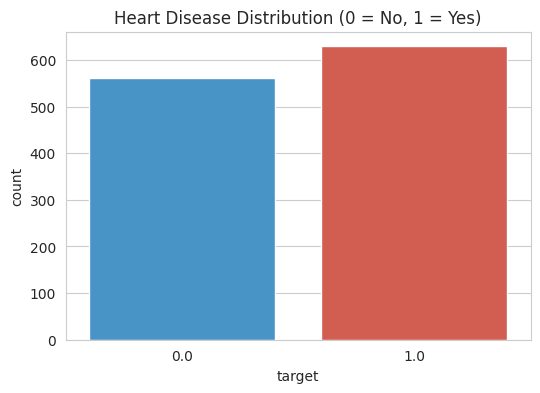

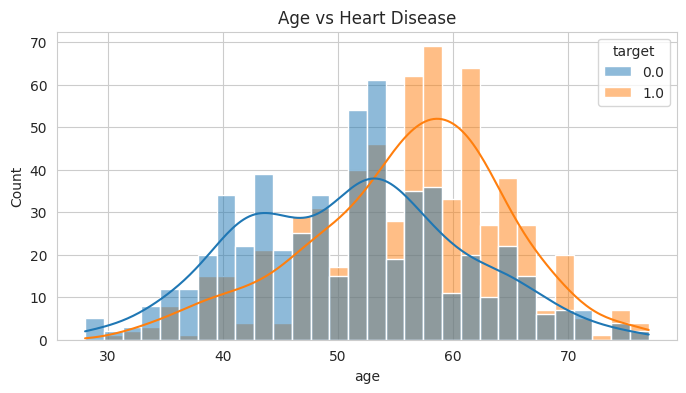

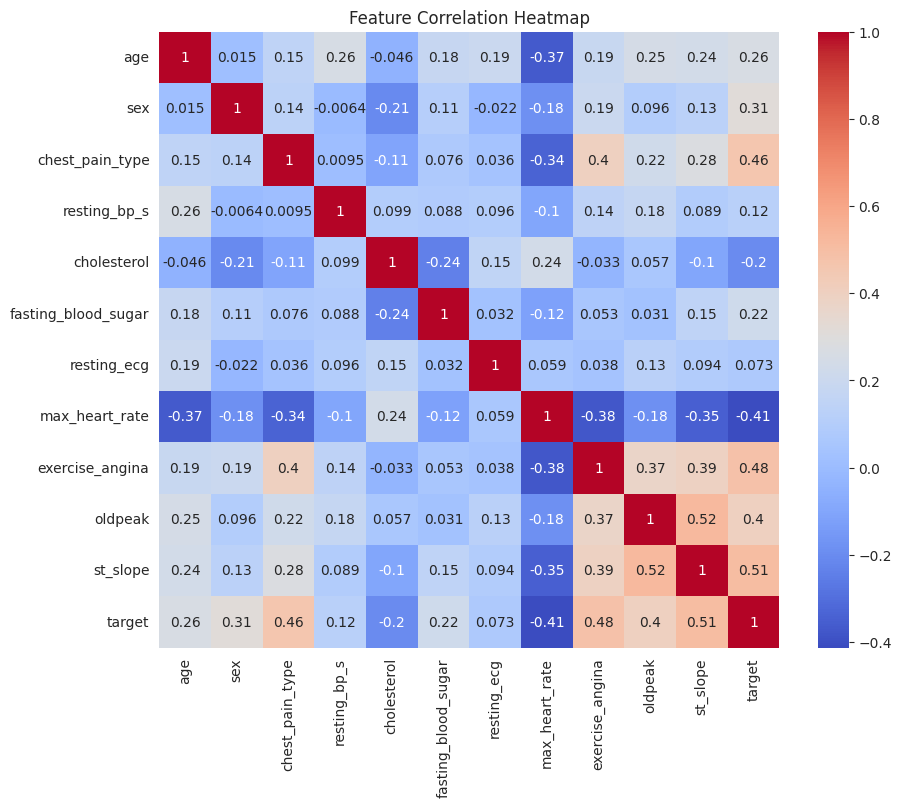

In [8]:
# Check how many people have heart disease (target variable)
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette=['#3498db', '#e74c3c'])
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

# See age pattern with disease
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='age', hue='target', bins=30, kde=True)
plt.title("Age vs Heart Disease")
plt.show()

# Check correlation between features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [9]:
# Separate input (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features to improve model accuracy
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling complete!")


Data scaling complete!


In [10]:
# Create and train four models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42)
}

# Train each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully!")


Logistic Regression trained successfully!
Random Forest trained successfully!
Gradient Boosting trained successfully!
Support Vector Machine trained successfully!


In [11]:
# Test each model and store results
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_pred_prob)
    }

# Show model performance
results_df = pd.DataFrame(results).T.sort_values(by='Accuracy', ascending=False)
display(results_df.style.background_gradient(cmap='Blues'))


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.928571,0.929134,0.936508,0.932806,0.970734
Gradient Boosting,0.903361,0.905512,0.912698,0.909091,0.949617
Support Vector Machine,0.878151,0.864662,0.912698,0.888031,0.935232
Logistic Regression,0.840336,0.843750,0.857143,0.850394,0.904053


In [12]:
# Check model stability with 5-fold cross-validation
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name} - Cross Validation Accuracy: {scores.mean():.4f}")


Logistic Regression - Cross Validation Accuracy: 0.8246
Random Forest - Cross Validation Accuracy: 0.9097
Gradient Boosting - Cross Validation Accuracy: 0.8750
Support Vector Machine - Cross Validation Accuracy: 0.8582


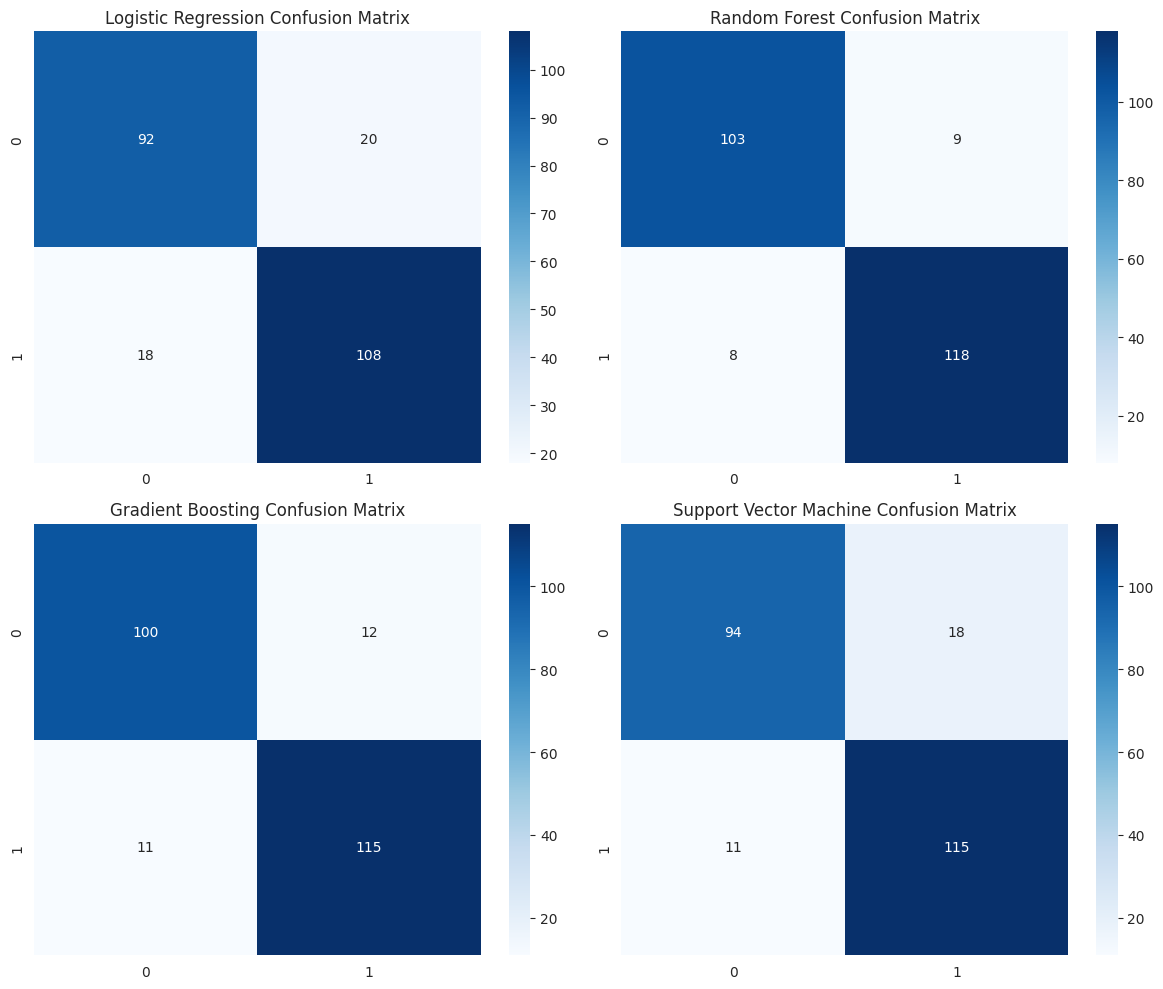

In [13]:
# Show confusion matrix for each model
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()


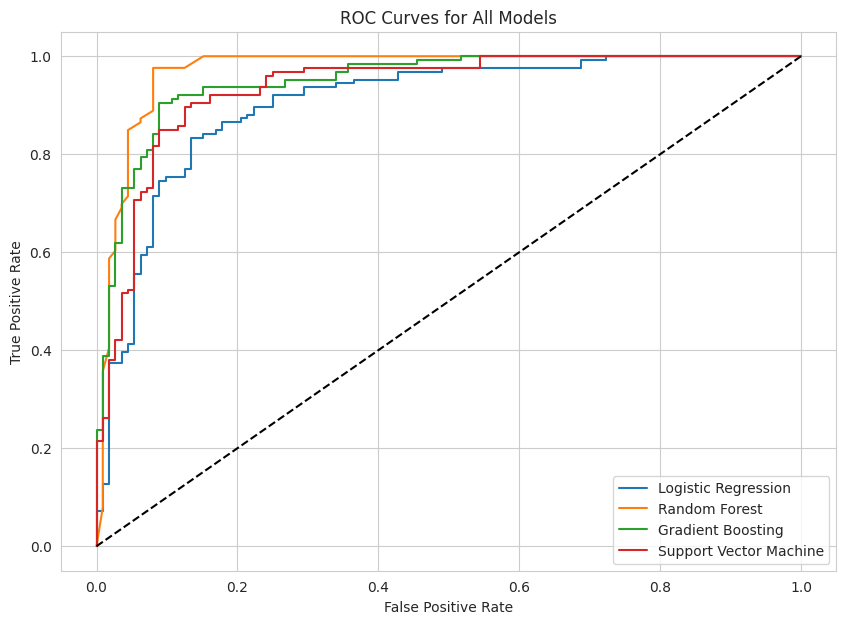

In [14]:
# Compare model ROC curves
plt.figure(figsize=(10,7))
for name, model in models.items():
    y_pred_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


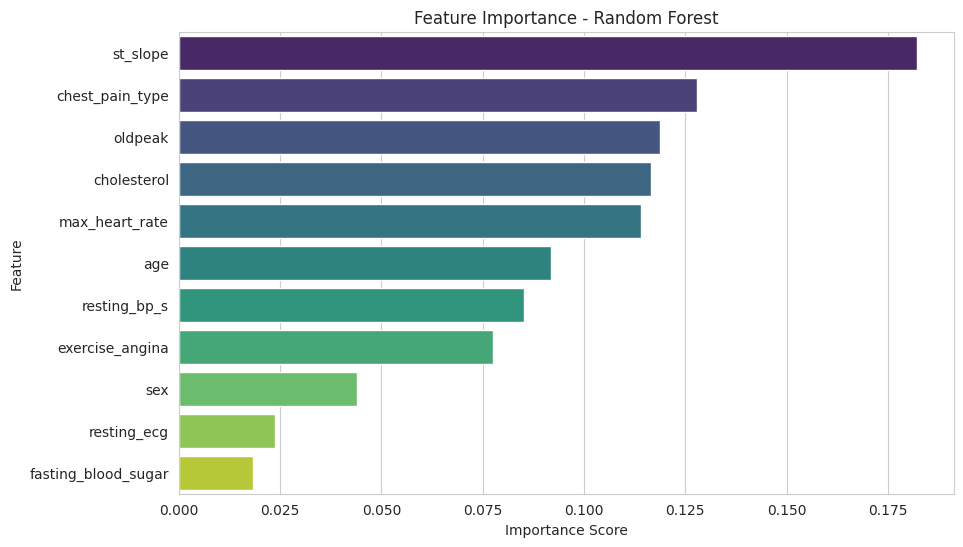

In [15]:
# Check which features are most important in Random Forest
rf = models["Random Forest"]
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [16]:
# Show best model and accuracy
best_model = results_df['Accuracy'].idxmax()
best_score = results_df['Accuracy'].max()

print(f"Best Model: {best_model}")
print(f"Accuracy: {best_score:.4f}")

Best Model: Random Forest
Accuracy: 0.9286
